In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\bless\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [35]:
df = pd.read_csv(r'C:\Users\bless\OneDrive\Desktop\banking-app-reveiws\data\mobile_banking_reviews.csv')

In [36]:
print(df.head())
print(f"Total reviews: {len(df)}")

                          bank  \
0  Commercial Bank of Ethiopia   
1  Commercial Bank of Ethiopia   
2  Commercial Bank of Ethiopia   
3  Commercial Bank of Ethiopia   
4  Commercial Bank of Ethiopia   

                                              review  rating        date  \
0  "Why don’t your ATMs support account-to-accoun...       4  2025-06-06   
1                        what is this app problem???       1  2025-06-05   
2       the app is proactive and a good connections.       5  2025-06-05   
3    I cannot send to cbebirr app. through this app.       3  2025-06-05   
4                                               good       4  2025-06-05   

        source  
0  Google Play  
1  Google Play  
2  Google Play  
3  Google Play  
4  Google Play  
Total reviews: 986


In [37]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\bless\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bless\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\bless\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\bless\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [38]:
def preprocess_text(text):
    tokens = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalnum() and word not in stop_words]
    return ' '.join(tokens)

df['processed_review'] = df['review'].astype(str).apply(preprocess_text)

In [39]:
def get_sentiment(text):
    analysis = TextBlob(text)
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_textblob'] = df['processed_review'].apply(get_sentiment)


In [40]:
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = sia.polarity_scores(text)
    if scores['compound'] > 0.05:
        return 'positive'
    elif scores['compound'] < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_vader'] = df['review'].astype(str).apply(get_vader_sentiment)

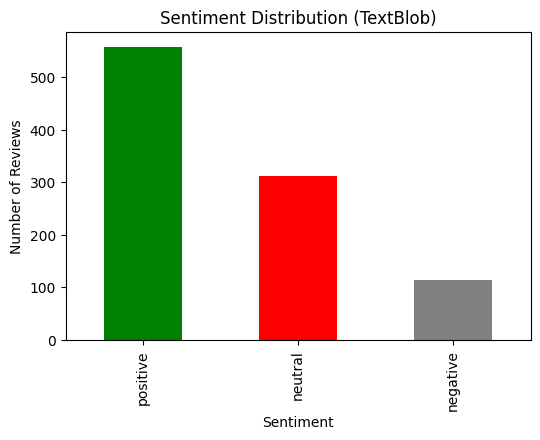

In [41]:
plt.figure(figsize=(6,4))
df['sentiment_textblob'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


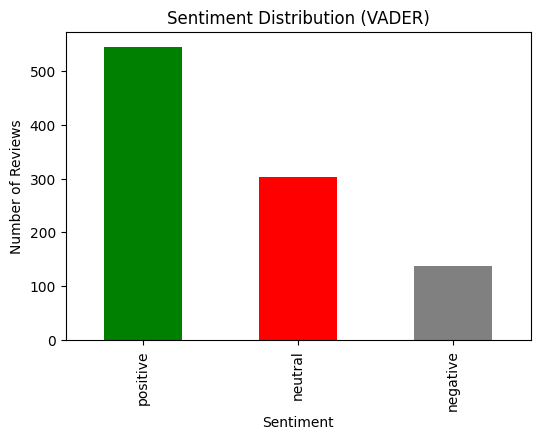

In [42]:
plt.figure(figsize=(6,4))
df['sentiment_vader'].value_counts().plot(kind='bar', color=['green', 'red', 'gray'])
plt.title('Sentiment Distribution (VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [43]:
df['polarity'] = df['processed_review'].apply(lambda x: TextBlob(x).sentiment.polarity)

sentiment_summary = df.groupby(['bank', 'rating'])['polarity'].mean().reset_index()
print(sentiment_summary)

                           bank  rating  polarity
0             Bank of Abyssinia       1 -0.094311
1             Bank of Abyssinia       2  0.093939
2             Bank of Abyssinia       3  0.079761
3             Bank of Abyssinia       4  0.252126
4             Bank of Abyssinia       5  0.307660
5   Commercial Bank of Ethiopia       1 -0.025991
6   Commercial Bank of Ethiopia       2  0.058660
7   Commercial Bank of Ethiopia       3  0.107333
8   Commercial Bank of Ethiopia       4  0.357440
9   Commercial Bank of Ethiopia       5  0.386488
10                  Dashen Bank       1  0.092545
11                  Dashen Bank       2 -0.009178
12                  Dashen Bank       3  0.256278
13                  Dashen Bank       4  0.223744
14                  Dashen Bank       5  0.377991


In [44]:
def extract_keywords(data, n=10):
    vectorizer = TfidfVectorizer(max_features=n)
    X = vectorizer.fit_transform(data)
    return vectorizer.get_feature_names_out()

print("Top keywords per bank:")

for bank in df['bank'].unique():
    bank_reviews = df[df['bank'] == bank]['processed_review']
    keywords = extract_keywords(bank_reviews)
    print(f"\n{bank} top keywords:\n", keywords)

Top keywords per bank:

Commercial Bank of Ethiopia top keywords:
 ['app' 'application' 'bank' 'banking' 'best' 'cbe' 'good' 'like' 'make'
 'nice']

Dashen Bank top keywords:
 ['app' 'bank' 'banking' 'dashen' 'easy' 'fast' 'feature' 'one' 'super'
 'use']

Bank of Abyssinia top keywords:
 ['app' 'bank' 'banking' 'boa' 'mobile' 'please' 'time' 'use' 'work'
 'working']


In [46]:
themes = {
    "Account Access Issues": ['login', 'password', 'access', 'locked'],
    "Transaction Performance": ['slow', 'transfer', 'delay', 'transaction', 'processing'],
    "User Interface & Experience": ['app', 'ui', 'design', 'crash', 'easy'],
    "Customer Support": ['support', 'help', 'service', 'response', 'call'],
    "Feature Requests": ['feature', 'update', 'add', 'improve']
}

def assign_themes(text):
    assigned = []
    for theme, keywords in themes.items():
        for kw in keywords:
            if kw in text:
                assigned.append(theme)
                break
    return assigned if assigned else ['Other']

df['themes'] = df['processed_review'].apply(assign_themes)

In [47]:
df.to_csv(r'C:\Users\bless\OneDrive\Desktop\banking-app-reveiws\data/mobile_banking_reviews_with_sentiment_themes.csv', index=False)



Theme distribution per bank:

Commercial Bank of Ethiopia theme counts:
themes
Other                          156
User Interface & Experience    131
Transaction Performance         18
Feature Requests                16
Customer Support                15
Account Access Issues            9
Name: count, dtype: int64


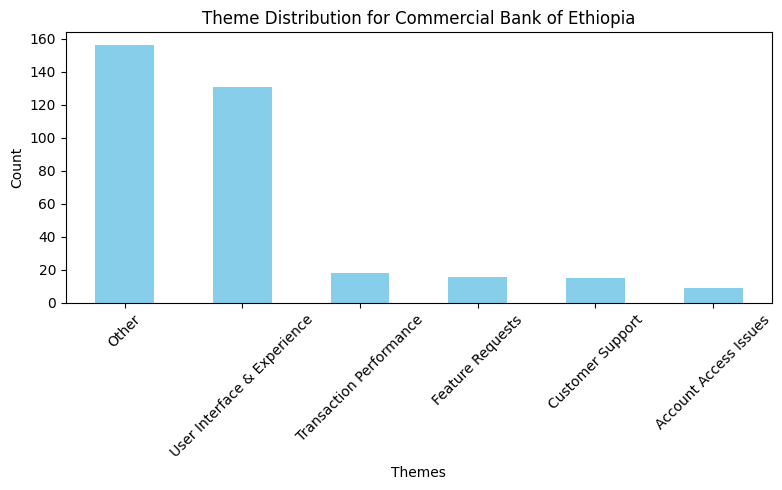


Dashen Bank theme counts:
themes
User Interface & Experience    207
Other                          104
Feature Requests                57
Transaction Performance         48
Customer Support                28
Account Access Issues            9
Name: count, dtype: int64


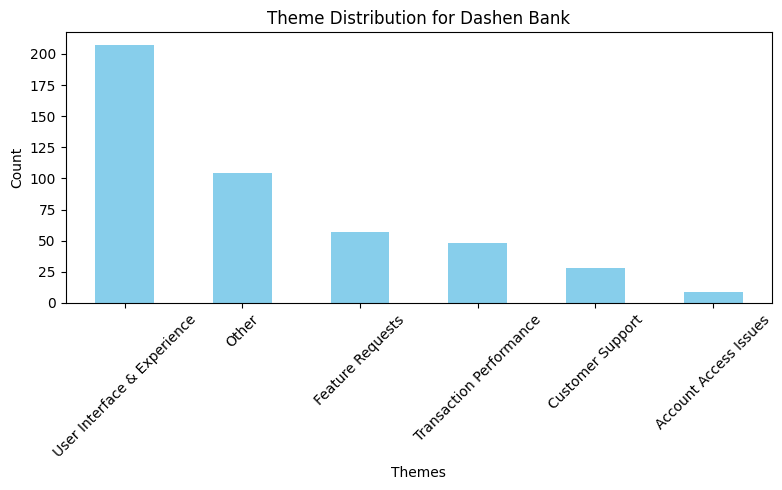


Bank of Abyssinia theme counts:
themes
Other                          158
User Interface & Experience    143
Transaction Performance         27
Feature Requests                27
Customer Support                23
Account Access Issues            9
Name: count, dtype: int64


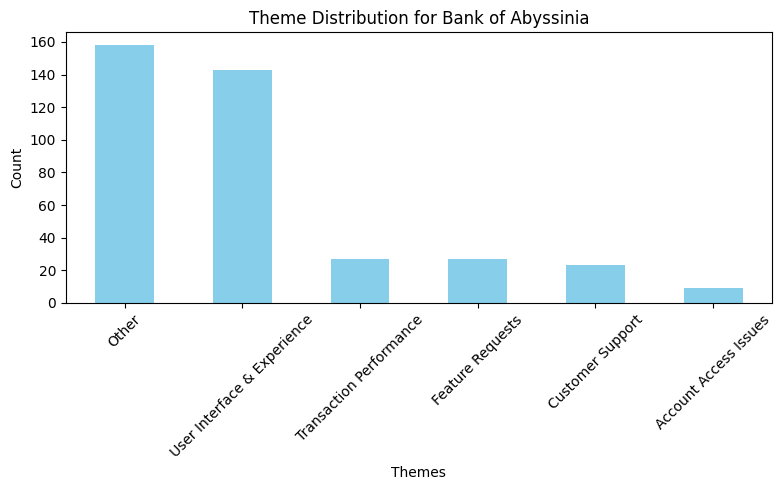

In [49]:
print("\nTheme distribution per bank:")
for bank in df['bank'].unique():
    bank_df = df[df['bank'] == bank]
    theme_counts = bank_df['themes'].explode().value_counts()
    print(f"\n{bank} theme counts:\n{theme_counts}")

    
    plt.figure(figsize=(8,5))
    theme_counts.plot(kind='bar', color='skyblue')
    plt.title(f"Theme Distribution for {bank}")
    plt.xlabel('Themes')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [50]:
positive_text = ' '.join(df[df['sentiment_textblob'] == 'positive']['processed_review'])
negative_text = ' '.join(df[df['sentiment_textblob'] == 'negative']['processed_review'])

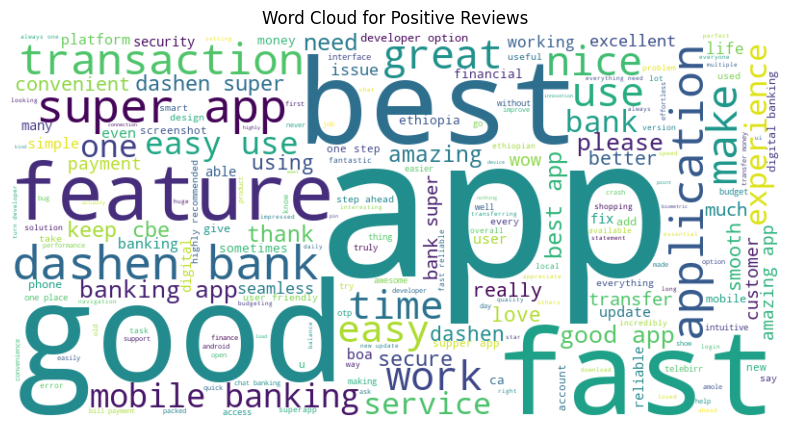

In [51]:
plt.figure(figsize=(10,5))
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

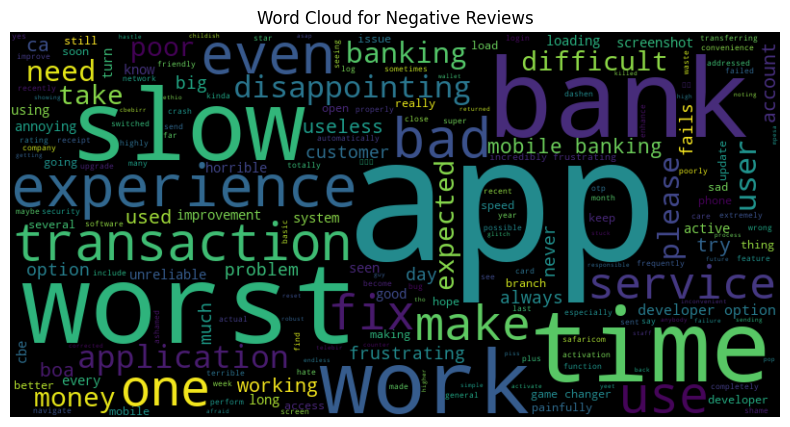

In [52]:
plt.figure(figsize=(10,5))
wordcloud_neg = WordCloud(width=800, height=400, background_color='black').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Reviews')
plt.show()